#*Fun with Probabilities*

### Meme 1

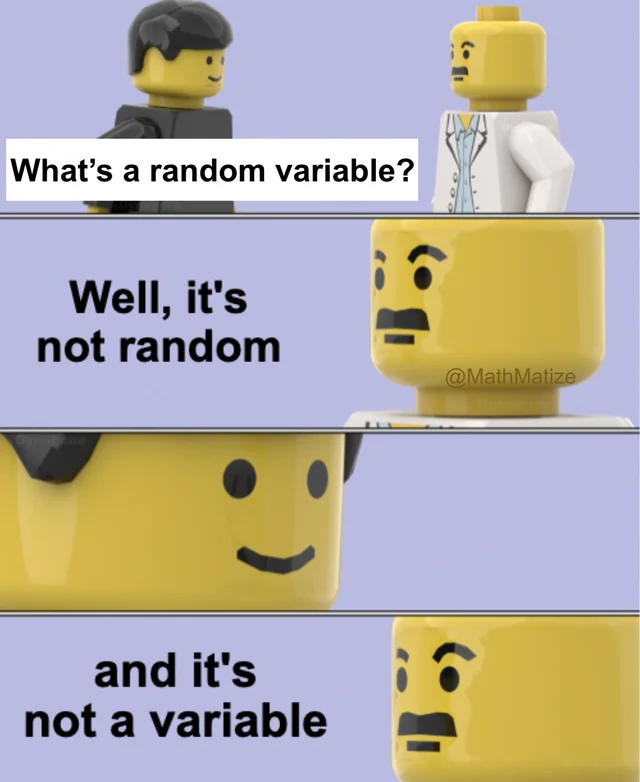

## Meme 2

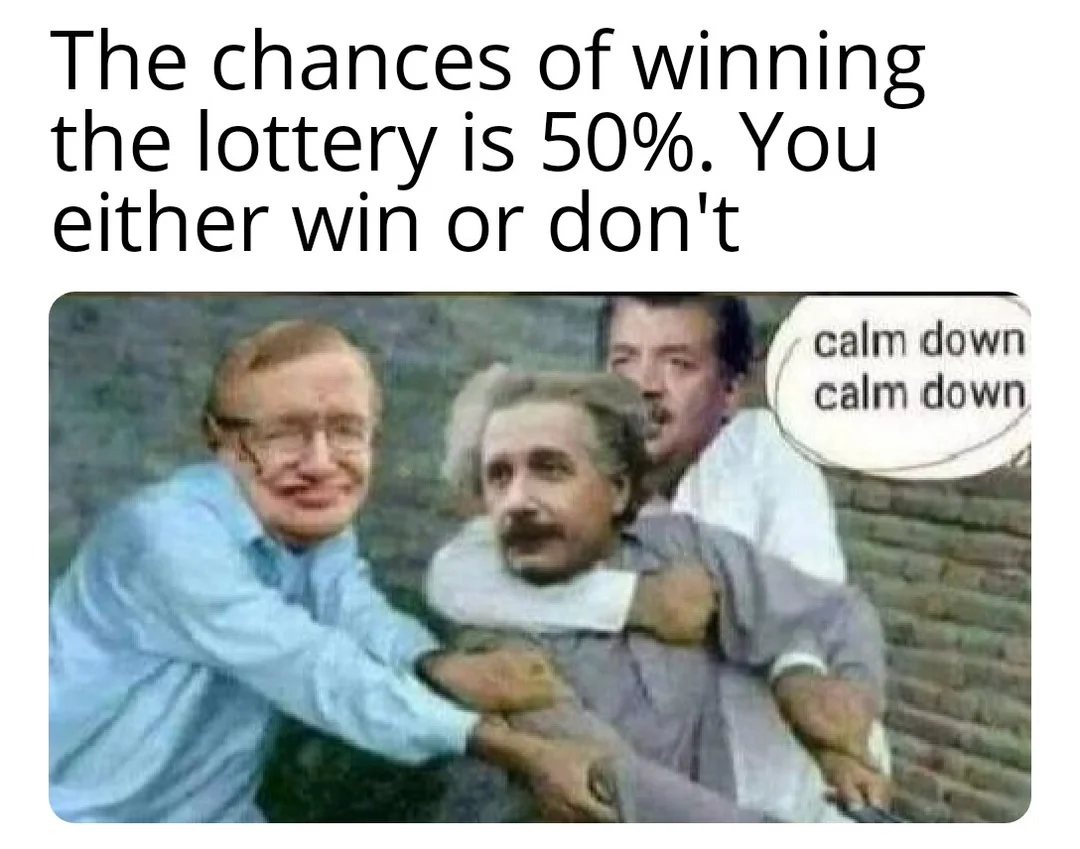

## Problema 1 - Existe Livre-arbítrio?




**Pergunta filosófica (brincadeira):** se uma máquina consegue adivinhar o resultado de uma escolha humana (binária e arbitrária) com probabilidade $> \frac{1}{2}$, é possível dizer que temos livre-arbítrio?

*What?* Achei que tava na aula de Ciência de Dados!

Façamos um experimento simples.

https://roadtolarissa.com/oracle/

## Problema 2 - Monty Hall *Problem*

No Brasil, uma versão popular desse problema era conhecida com "Portas dos Desesperados".

0. O participante de um programa está diante de três portas.
- Em uma, há um prêmio
- Nas duas outras, há monstros

1. O Participante escolhe uma porta, na qual acredita que esteja o prêmio

2. Das portas que o participante não escolheu, o Apresentador revela uma que tem monstro. Assim, das não reveladas, uma tem monstro e a outra tem prêmio

3. O Apresentador oferece ao participante a chance de trocar de porta

4. Após a decisão, a porta escolhida pelo participante é revelada.

O Objetivo, obviamente, é ganhar e escolher a porta com o prêmio.

Vejamos uma simulação



https://montyhall.io/

Perguntas:
1. Qual a chance do participante ganhar?
2. Quando apresentado com a opção de troca, é melhor trocar, não trocar ou escolher entre as duas aleatoriamente?

### Versão Simplificada

Nessa versão simplificada, não existe a opção de troca. Vamos fazer uma simulação.

In [ ]:
import random

def play_basic_game():

  # Configuração do jogo. Dois monstros e um Prêmio
  # Opções estão embaralhadas
  options = ['Monstro', 'Monstro', 'Prêmio']
  random.shuffle(options)

  # Escolha do usuário
  # Poderia fixar a escolha aqui, dado que as opções
  # foram embaralhadas
  choice = random.choice(options)

  # Retorna True de Ganhou e False se Perdeu
  return choice == 'Prêmio'

Qual a Probabilidade de um Jogador ganhar o Jogo? Ou seja, qual a Probabilidade da função acima retornar ``True``?

In [ ]:
import numpy as np

results = []
for i in range(10000):
  results.append(play_basic_game())

print(np.mean(results))

0.3249


#### Resposta

Esse é um caso bem simples de analisar. Há três portas, em uma escolha aleatória simples, a chance de encontrar o prêmio é $\frac{1}{3}$.

### Versão Geral

Vamos agora fazer uma simulação do problema original. Veja o código abaixo.

In [ ]:
# p é a probabilidade de que um usuário irá trocar de porta
# quando a oportunidade for dada
def play_original_game(p = 0.5):

  # Configuração do jogo. Dois monstros e um Prêmio
  # Opções estão embaralhadas
  options = ['Monstro 1', 'Monstro 2', 'Prêmio']
  random.shuffle(options)
  #print("Portas:", options)

  # Jogador faz a escolha inicial. Como no caso anterior, poderia
  # ser uma escolha fixa também. Aqui, mudei para ídice pois fica mais
  # fácil de implementar
  options_idx = [0, 1, 2]
  choice = random.choice(options_idx)
  #print("Jogador escolheu porta %d, que tem %s" % (choice, options[choice]))

  # abre uma porta e mostra onde um dos monstros está
  # Se o jogador tiver escolhido a porta com prêmio,
  # Apresentador escolhe uma porta arbitrária
  candidates_to_open = []
  for i in range(len(options)):
    if i != choice and options[i] != 'Prêmio':
      candidates_to_open.append(i)
  to_open = random.choice(candidates_to_open)
  #print('Apresentador revela porta %d, quem tem %s' % (to_open, options[to_open]))

  # oferece a escolha, gostaria de trocar?
  # Vamos assumir que o Jogador troca com probabilidade p
  if random.random() < p:
    #print('Decidiu Trocar!')
    new_choice, = set(options_idx) - set([choice, to_open])
  else:
    #print('Decidiu não Trocar')
    new_choice = choice

  # Revela resultado
  #print('Jogador ficou com a porta %d, que tem %s!' % (new_choice, options[new_choice]))

  # Retorna True de Ganhou e False se Perdeu
  return options[new_choice] == 'Prêmio'

In [ ]:
play_original_game();

#### Caso 1, Troca com Probabilidade $\frac{1}{2}$

Vejamos o que acontece quando os participantes decidem trocar ou não aleatoriamente (50% de chances de trocar)

In [ ]:
import numpy as np

results = []
for i in range(10000):
  results.append(play_original_game())

print(np.mean(results))

0.497


#### Caso 2, Nunca troca

Agora, quando o participante nunca troca, ou seja $p = 0$

In [ ]:
import numpy as np

results = []
for i in range(10000):
  results.append(play_original_game(p = 0))

print(np.mean(results))

0.3367


#### Caso 3, Sempre troca

Por fim, o caso em que o participante sempre troca ($p = 1$)

In [ ]:
import numpy as np

results = []
for i in range(10000):
  results.append(play_original_game(p = 1))

print(np.mean(results))

0.6663


### Análise Teórica

O que está acontecendo, isso faz sentido? Vamos fazer uma análise mais teórica da situação.

#### Definição dos Eventos


- $M$ O participante escolheu a porta com monstro na primeira escolha
- $\bar{M}$ O participante escolheu a porta com prêmio na primeira escolha
- $T$ Quando dada a oportunidade, o participante decidiu trocar de porta
- $\bar{T}$ Quando dada a oportunidade, o participante decidiu **não** trocar de porta


#### Probabilidades dadas no enunciado/descrição

- $P(M) = \frac{2}{3}$
- $P(\bar{M}) = \frac{1}{3}$
- $P(T) = p$
- $P(\bar{T}) = 1 - p$


#### Probabilidade de Ganhar

O participante ganha quando:
- Escolhe o prêmio na primeira escolha **E** decide não trocar de porta; **OU**
- Escolhe o monstro na primeira escolha **E** decide trocar de porta.
Logo

$$
P(\text{Ganhar})  =  P(\bar{M} \cap \bar{T}) + P(M \cap T)
$$

Utilizando probabilidade condicional, temos que:


$$
P(\text{Ganhar})  =  P(\bar{M})P(\bar{T}|\bar{M}) + P(M)P(T|M)
$$

Substituindo os valores definidos no problema, temos que:

$$
P(\text{Ganhar})  =  \frac{1}{3}(1-p) + \frac{2}{3}p = \frac{1+p}{3}
$$

No resultado acima, fazendo:
- $p = \frac{1}{2}$, temos $P(\text{Ganhar}) = \frac{1}{2}$
- $p = 0$, temos $P(\text{Ganhar}) = \frac{1}{3}$
- $p = 1$, temos $P(\text{Ganhar}) = \frac{2}{3}$.

Assim, veja que:
- Esses resultados são compatíveis com nossa análise empírica!
- Sempre trocar de porta é a política que maximiza sua chance de ganhar!

## Problema 3 - Lei dos Grandes Números

Um resultado muito interessante da teoria de probabilidade é a Lei dos Grandes Números.

Esse resultado nos mostra o que esperar (caso médio) de um evento que se repete muitas e muitas vezes.

Sem saber, nós vimos exemplos de aplicações dessa Lei nos experimentos acima.

Quando repetimos cada experimento muitas vezes, a fração de sucessos convergiu para a probabilidade teórica de sucesso de um evento.

Vejamos uma versão dessa lei [aqui](https://pt.wikipedia.org/wiki/Lei_dos_grandes_n%C3%BAmeros).

Vamos agora, observar o comportamento da Lei dos Grandes Números em algumas distribuições conhecidas.


### Distribuição [Exponencial](https://en.wikipedia.org/wiki/Exponential_distribution)

Vamos utilizar a biblioteca ``scipy``, do Python, para gerar números pseudoaleatórios dessa distribuição.

In [ ]:
#https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html
from scipy.stats import expon

In [ ]:
# Parâmetro lambda da distribuição
l = 1

In [ ]:
# gerando uma amostra de tamanho size.
x = expon.rvs(size = 10000, scale = 1 / l)

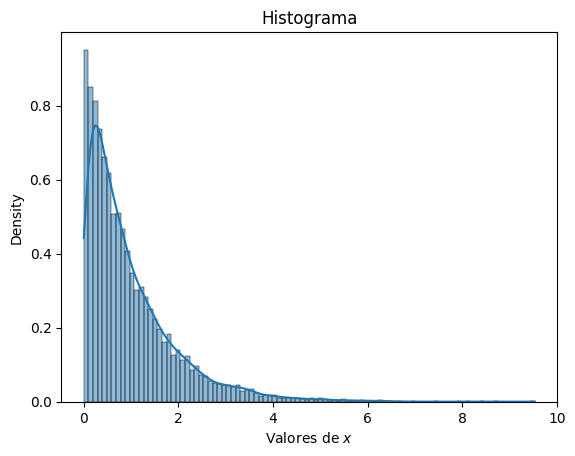

In [ ]:
# histograma dos dados gerados
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ax = sns.histplot(data = pd.DataFrame(x), kde=True, stat = 'density', legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma');

In [ ]:
# calculando a média dos valores da amostra
print(np.mean(x))

0.9710240954033108


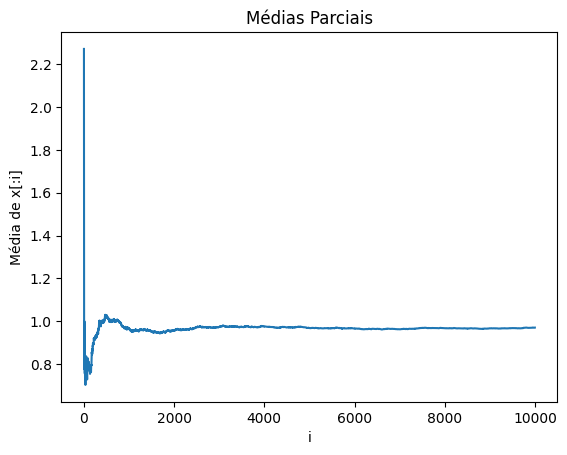

In [ ]:
# fazendo um gráfico com as médias parciais do vetor de números gerados
partials = []
for i in range(1, len(x)):
  partials.append(np.mean(x[:i]))

plt.plot(list(range(1, len(x))), partials);
plt.title('Médias Parciais')
plt.xlabel('i')
plt.ylabel(r'Média de x[:i]');

De forma empírica, acabamos de ver um outro exemplo da Lei dos Grandes Números.


### Distribuição [Normal](https://en.wikipedia.org/wiki/Normal_distribution)

Vamos repetir agora, o mesmo experimento para a distribuição normal.

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html
from scipy.stats import norm

In [ ]:
# Parâmetro lambda da distribuição
mu = 0
sigma = 1

In [ ]:
x = norm.rvs(size = 10000, loc = mu, scale = sigma)

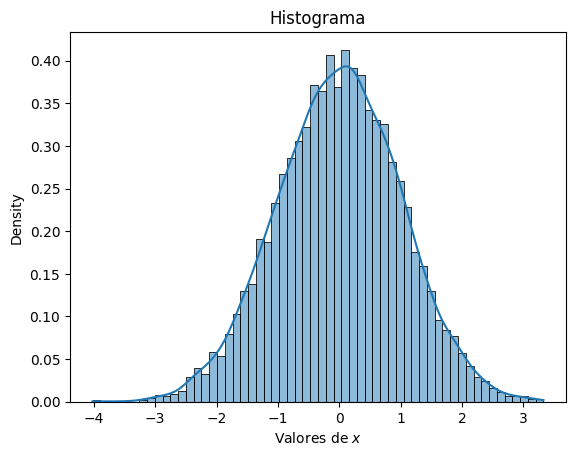

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ax = sns.histplot(data = pd.DataFrame(x), kde=True, stat = 'density', legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma');

In [ ]:
print(np.mean(x))

-0.0033769266511333015


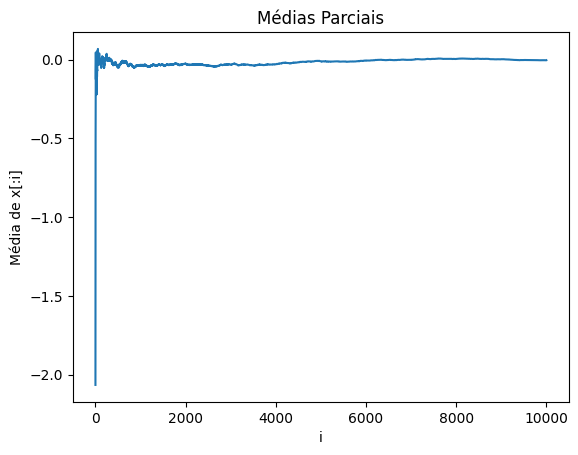

In [ ]:
partials = []
for i in range(1, len(x)):
  partials.append(np.mean(x[:i]))

plt.plot(list(range(1, len(x))), partials);
plt.title('Médias Parciais')
plt.xlabel('i')
plt.ylabel(r'Média de x[:i]');

Novamente, veja que o valor da média está convergindo para o valor real de $\mu$ à medida que aumentamos o tamanho da amostra.


### Distribuição [Binomial](https://en.wikipedia.org/wiki/Binomial_distribution)

Vamos agora olhar para o caso de uma distribuição discreta. Será que o resultado ainda vale?

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binom.html
from scipy.stats import binom

In [ ]:
# Parâmetro lambda da distribuição
n = 10
p = 0.1

In [ ]:
x = binom.rvs(size = 10000, n = n, p = p)

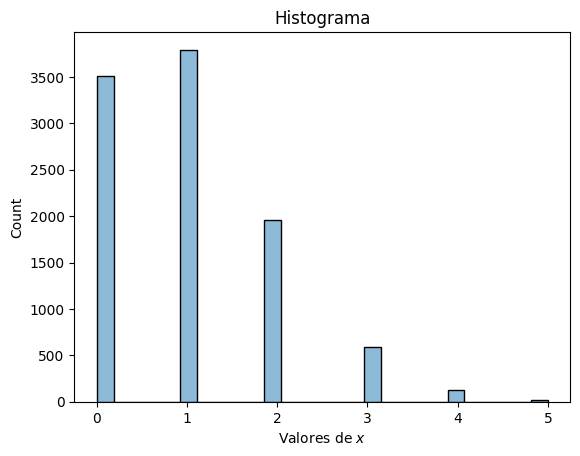

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Warning: Fiz um histograma aqui apenas a título de comparação e para mostrar a forma
# da distribuição. Ha maneiras melhores de visualizar esse tipo de distribuição
# Próximas aulas...
ax = sns.histplot(data = pd.DataFrame(x), legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma');

In [ ]:
print(np.mean(x))

1.0075


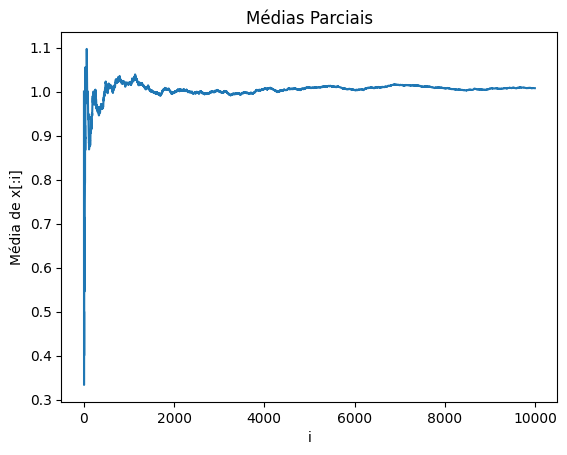

In [ ]:
partials = []
for i in range(1, len(x)):
  partials.append(np.mean(x[:i]))

plt.plot(list(range(1, len(x))), partials);
plt.title('Médias Parciais')
plt.xlabel('i')
plt.ylabel(r'Média de x[:i]');

Novamente, veja que as médias parciais estão convergindo para o valor esperado, que é $np$.

### E se misturarmos?

Veja agora um resultado em que misturamos elementos de várias distribuições.

In [ ]:
x = list(expon.rvs(size = 3000, scale = 1 / l)) + list(norm.rvs(size = 3000, loc = mu, scale = sigma)) + list(binom.rvs(size = 3000, n = n, p = p))
random.shuffle(x) # o shuffle é iportante? por quê?

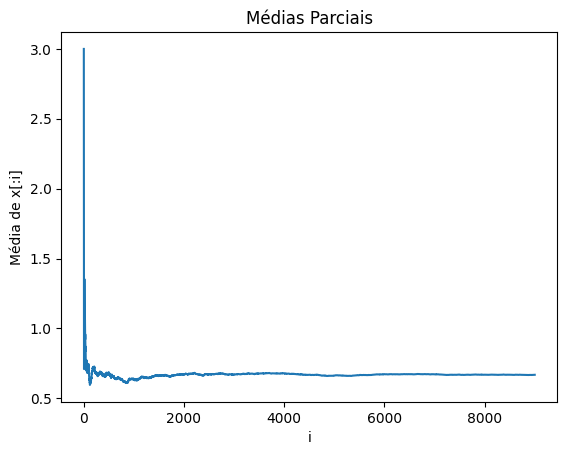

In [ ]:
partials = []
for i in range(1, len(x)):
  partials.append(np.mean(x[:i]))

plt.plot(list(range(1, len(x))), partials);
plt.title('Médias Parciais')
plt.xlabel('i')
plt.ylabel(r'Média de x[:i]');

Quando misturamos as amostras, ainda há convergência. Nesse caso, como todas as amostrar têm o mesmo tamanho, a convergência será para $\frac{\frac{1}{\lambda}+ \mu + np}{3}$.


### Distribuição de [Cauchy](https://en.wikipedia.org/wiki/Cauchy_distribution)

Repetindo para uma outra distribuição, a Cauchy.

In [ ]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.cauchy.html
from scipy.stats import cauchy

In [ ]:
x = cauchy.rvs(size = 2000)

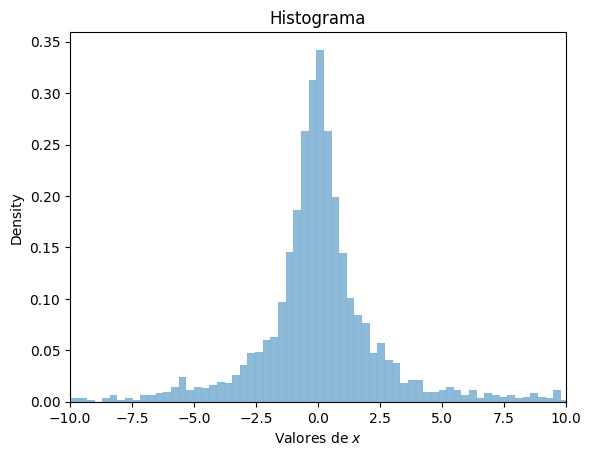

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ax = sns.histplot(data = pd.DataFrame(x), stat = 'density', legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma', xlim = (-10, 10));

In [ ]:
print(np.mean(x))

-0.49912826739620436


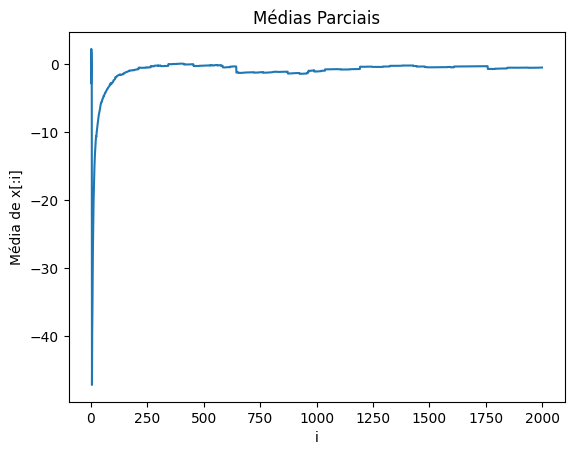

In [ ]:
partials = []
for i in range(1, len(x)):
  partials.append(np.mean(x[:i]))

plt.plot(list(range(1, len(x))), partials);
plt.title('Médias Parciais')
plt.xlabel('i')
plt.ylabel(r'Média de x[:i]');

##### O que está acontecendo?

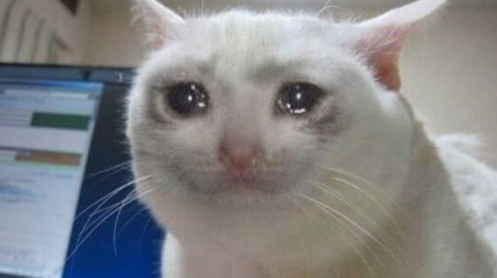

Voltemos à teoria para entender...


### Distribuição de [Pareto](https://en.wikipedia.org/wiki/Pareto_distribution)

Outro exemplo que não segue o padrão esperado (?)

In [ ]:
# https://docs.scipy.org/doc/scipy-1.16.2/reference/generated/scipy.stats.pareto.html
from scipy.stats import pareto

In [ ]:
# Testar e mostrar comportamento para alpha = 1, 2 e 3

alpha = 1

x = pareto.rvs(size = 2000, b = alpha)

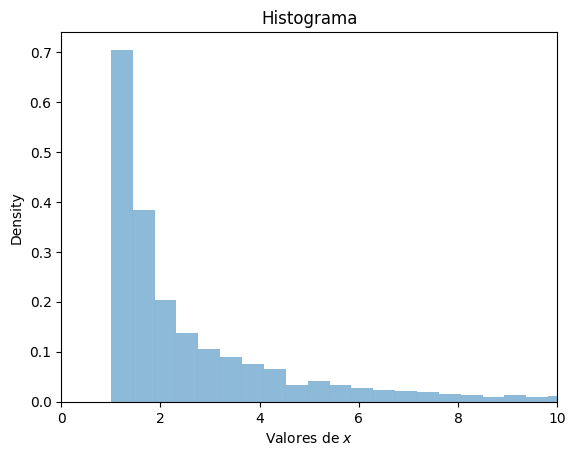

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

ax = sns.histplot(data = pd.DataFrame(x), stat = 'density', legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma', xlim = (0, 10));

In [ ]:
print(np.mean(x))

10.581096856050959


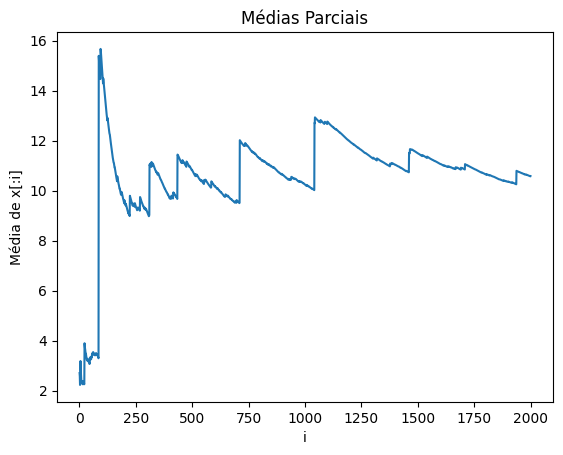

In [ ]:
partials = []
for i in range(1, len(x)):
  partials.append(np.mean(x[:i]))

plt.plot(list(range(1, len(x))), partials);
plt.title('Médias Parciais')
plt.xlabel('i')
plt.ylabel(r'Média de x[:i]');

##### Em resumo

Veja que o comportamento muda em função dos valores escolhidos para o parâmetro da distribuição!

**Certos comportamentos em um conjunto de dados a gente só entende quando temos conhecimento da teoria!**

E sim, dados com esse tipo de distribuição ocorrem mais frequentemente do que imaginam. Veremos mais sobre isso em aulas futuras.

## Problema 4 - Teorema Central do Limite

Um outro resultado muito interessante da teoria de probabilidade é o Teorema Central do Limite.

Antes de enunciarmos o Teorema, vejamos um experimento.

Primeiro, vamos gerar números pseudoaleatórios utilizando as mesmas distribuições do exemplo anterior.

In [ ]:
from scipy.stats import norm

In [ ]:
# 1 Parâmetro mu e sigma da distribuição
#mu = 0
#sigma = 1
#x = norm.rvs(size = 10000, loc = mu, scale = sigma)

# 2 Parâmetro lambda da distribuição
l = 1
x = expon.rvs(size = 10000, scale = 1 / l)

# 3 Parâmetros n e p da distribuição
#n = 100
#p = 0.1
#x = binom.rvs(size = 10000, n = n, p = p)

No nosso novo experimento vamos:
1. Selecionar uma amostra aleatória, de tamanho $n$, do conjunto de dados original
2. Calcular a média da amostra aleatória obtida em (1)
3. Repetir (1) e (2) $N$ vezes

In [ ]:
N = 10000
n = 30 # lembrar de variar

# aqui teremos as N médias computadas
means = []
for i in range(N):
  means.append(np.mean(random.choices(x, k = n)))

**Pergunta:** qual a distribuição das médias calculadas?

Para ganhar uma intuição sobre o problema, vamos observar o histograma das médias computadas no experimento acima.

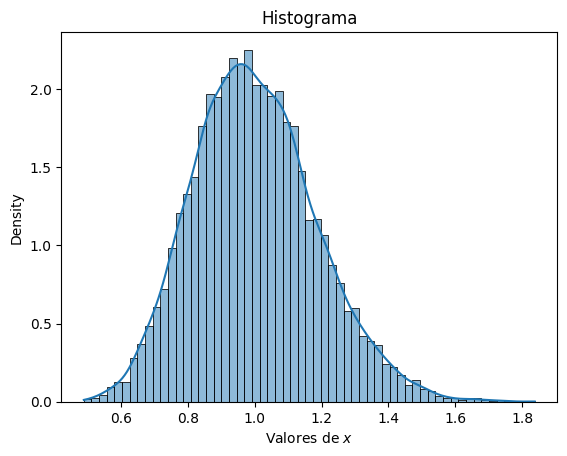

In [ ]:
ax = sns.histplot(data = pd.DataFrame(means), kde=True, stat = 'density', legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma');

##### Em resumo

Como vocês podem ver, independentemente das distribuições originais do conjunto de dados, a distribuição da média amostral converge para a distribuição Normal!

E é justamente sobre isso que é o Teorema Central do Limite. Vejamos o teorema [aqui](https://en.wikipedia.org/wiki/Central_limit_theorem).

Esse é um dos teoremas mais importantes da Probabilidade e Estatística. A partir dele, conseguimos construir vários tipos de Intervalos de confiança e Testes de Hipóteses.

Mas será que é sempre assim? Vamos ver qual o comportamento quando utilizamos as distribuições de Cauchy e Pareto.

In [ ]:
# 4
#x = cauchy.rvs(size = 10000)

# 5
x = pareto.rvs(size = 10000, b = 1) # testar alpha = 1, 2 e 3

In [ ]:
N = 10000
n = 200 # lembrar de variar

# aqui teremos as N médias computadas
means = []
for i in range(N):
  means.append(np.mean(random.choices(x, k = n)))

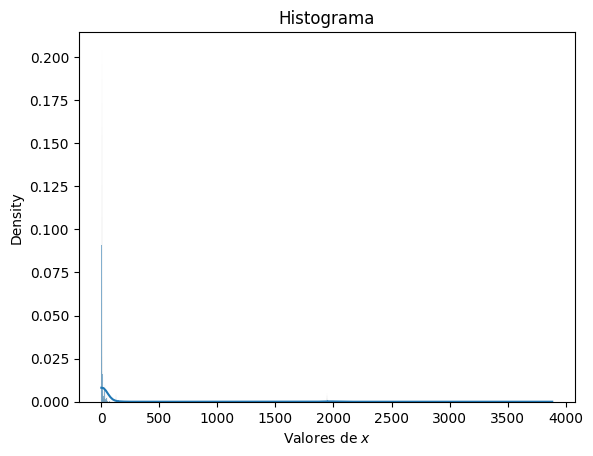

In [ ]:
ax = sns.histplot(data = pd.DataFrame(means), kde=True, stat = 'density', legend = False);
ax.set(xlabel=r'Valores de $x$', title = 'Histograma');

## Devo me importar com essas coisas?

Sim, e muito! Um bom conhecimento de Probabilidade será um diferencial para vocês. Tanto na disciplina quanto para os que quiserem pleitear uma carreira na área de Ciência de Dados.